# NB09A — Ensemble Extension (Holopainen & Sarlin, 2017)

**Purpose:** Implement model ensembling following Holopainen & Sarlin (2017), who demonstrate  
that averaging predicted probabilities across models consistently produces more stable and  
robust forecasts than selecting a single best model.

**No re-training is performed.** This notebook reads the out-of-sample (OOS) predicted  
probabilities saved by NB05A and constructs ensemble variants by averaging those probabilities.  
Metrics are computed on the same pooled OOS predictions used throughout the analysis.

## Ensemble variants evaluated

| Label | Models averaged | Evaluation window | Notes |
|-------|----------------|-------------------|-------|
| E1: Stage 2 | M2-matched + M3 | 2007–2018 (12 folds) | Cleanest comparison: identical training data |
| E2: Cross-stage 3-model | M2 (S1) + M2-matched + M3 | 2007–2018 overlap | M2 adds extended macro history |
| E3: Cross-stage 4-model | M1 + M2 (S1) + M2-matched + M3 | 2007–2018 overlap | All available models |

## Design constraints and honest framing

The cross-stage ensembles (E2, E3) combine models trained on different data windows:  
Stage 1 models (M1, M2) were trained on 1988–2020 data; Stage 2 models (M2-matched, M3)  
were trained on 2003–2020 only. In the 2007–2018 overlap window, Stage 1 models had  
substantially more training data per fold (up to 19 years vs 4 years for Stage 2).  
This asymmetry must be acknowledged when interpreting cross-stage ensemble results.  
All ensemble metrics are subject to the same single-episode GFC evaluation constraints  
established in Section 4.1 of Chapter 4.

**Inputs:** `data/processed/augmented_analysis/oos_predictions_stage1.csv`  
           `data/processed/augmented_analysis/oos_predictions_stage2.csv`  
**Output:** `data/processed/augmented_analysis/oos_predictions_ensemble.csv`  
            `figures/augmented_analysis/NB09A_ensemble_curves.png`

---

## Cell 1 — Imports and paths

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay
)

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
OUT_DIR = BASE / 'data' / 'processed' / 'augmented_analysis'
FIG_DIR = BASE / 'figures' / 'augmented_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

S1_CSV = OUT_DIR / 'oos_predictions_stage1.csv'
S2_CSV = OUT_DIR / 'oos_predictions_stage2.csv'

assert S1_CSV.exists(), f'Stage 1 OOS file not found: {S1_CSV}\nRun NB05A first.'
assert S2_CSV.exists(), f'Stage 2 OOS file not found: {S2_CSV}\nRun NB05A first.'

TARGET = 'target_h2'
RANDOM_STATE = 42
N_BOOTSTRAP  = 1000

print('✅  Imports and paths OK.')
print(f'   Stage 1 OOS : {S1_CSV}')
print(f'   Stage 2 OOS : {S2_CSV}')

✅  Imports and paths OK.
   Stage 1 OOS : C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\oos_predictions_stage1.csv
   Stage 2 OOS : C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\oos_predictions_stage2.csv


## Cell 2 — Load OOS predictions

In [5]:
s1 = pd.read_csv(S1_CSV)
s2 = pd.read_csv(S2_CSV)

print('Stage 1 OOS predictions')
print(f'  Shape   : {s1.shape}')
print(f'  Columns : {list(s1.columns)}')
print(f'  Years   : {s1["year"].min()}–{s1["year"].max()}')
print(f'  NaN prob_m1 : {s1["prob_m1"].isna().sum()}  |  NaN prob_m2 : {s1["prob_m2"].isna().sum()}')
print()
print('Stage 2 OOS predictions')
print(f'  Shape   : {s2.shape}')
print(f'  Columns : {list(s2.columns)}')
print(f'  Years   : {s2["year"].min()}–{s2["year"].max()}')
print(f'  NaN prob_m2m: {s2["prob_m2m"].isna().sum()}  |  NaN prob_m3: {s2["prob_m3"].isna().sum()}')
print()

# Check eval fold coverage — rows with non-null OOS predictions
s1_eval = s1.dropna(subset=['prob_m1', 'prob_m2'])
s2_eval = s2.dropna(subset=['prob_m2m', 'prob_m3'])

print(f'Stage 1 eval rows (non-null) : {len(s1_eval)}  |  Crisis events : {int(s1_eval[TARGET].sum())}')
print(f'  Eval years : {s1_eval["year"].min()}–{s1_eval["year"].max()}')
print()
print(f'Stage 2 eval rows (non-null) : {len(s2_eval)}  |  Crisis events : {int(s2_eval[TARGET].sum())}')
print(f'  Eval years : {s2_eval["year"].min()}–{s2_eval["year"].max()}')

Stage 1 OOS predictions
  Shape   : (569, 5)
  Columns : ['year', 'iso', 'target_h2', 'prob_m1', 'prob_m2']
  Years   : 1989–2020
  NaN prob_m1 : 102  |  NaN prob_m2 : 102

Stage 2 OOS predictions
  Shape   : (319, 5)
  Columns : ['year', 'iso', 'target_h2', 'prob_m2m', 'prob_m3']
  Years   : 2003–2020
  NaN prob_m2m: 104  |  NaN prob_m3: 104

Stage 1 eval rows (non-null) : 467  |  Crisis events : 28
  Eval years : 1993–2018

Stage 2 eval rows (non-null) : 215  |  Crisis events : 11
  Eval years : 2007–2018


## Cell 3 — Build E1: Stage 2 ensemble (M2-matched + M3)

The cleanest ensemble: both models trained on identical 2003–2020 data,  
same expanding-window folds, same evaluation observations.

In [7]:
# E1 operates directly on Stage 2 OOS — no merge required
e1 = s2_eval[['year', 'iso', TARGET, 'prob_m2m', 'prob_m3']].copy()
e1['prob_e1'] = (e1['prob_m2m'] + e1['prob_m3']) / 2

print('E1 — Stage 2 ensemble (M2-matched + M3)')
print(f'  Observations : {len(e1)}')
print(f'  Crisis events: {int(e1[TARGET].sum())}  (base rate {e1[TARGET].mean():.4f})')
print(f'  Eval years   : {e1["year"].min()}–{e1["year"].max()}')
print()
print('  Probability summary (E1 ensemble):')
print(e1[['prob_m2m', 'prob_m3', 'prob_e1']].describe().round(4).to_string())

E1 — Stage 2 ensemble (M2-matched + M3)
  Observations : 215
  Crisis events: 11  (base rate 0.0512)
  Eval years   : 2007–2018

  Probability summary (E1 ensemble):
       prob_m2m   prob_m3   prob_e1
count  215.0000  215.0000  215.0000
mean     0.1777    0.1665    0.1721
std      0.1727    0.2126    0.1834
min      0.0049    0.0000    0.0203
25%      0.0557    0.0356    0.0581
50%      0.1067    0.0889    0.0917
75%      0.2356    0.1786    0.1953
max      0.7377    1.0000    0.8658


## Cell 4 — Build cross-stage overlap dataset (E2, E3)

Merges Stage 1 and Stage 2 OOS predictions on `(year, iso)`.  
Inner join retains only observations where ALL four model predictions exist.  
This restricts the evaluation to the 2007–2018 window where Stage 2 eval folds begin.

**Design note:** Stage 1 models (M1, M2) had substantially more training data per fold  
in this window (trained from 1988 onward vs 2003 onward for Stage 2 models).  
This asymmetry is acknowledged in the framing but does not affect metric computation.

In [9]:
# Inner merge on (year, iso) — retains only the overlap window
s1_slim = s1_eval[['year', 'iso', TARGET, 'prob_m1', 'prob_m2']].rename(
    columns={TARGET: f'{TARGET}_s1'}  # rename to avoid collision on merge
)
s2_slim = s2_eval[['year', 'iso', TARGET, 'prob_m2m', 'prob_m3']]

overlap = pd.merge(s1_slim, s2_slim, on=['year', 'iso'], how='inner')
overlap = overlap.dropna(subset=['prob_m1', 'prob_m2', 'prob_m2m', 'prob_m3'])

# Verify targets are consistent across stages
target_mismatch = (overlap[TARGET] != overlap[f'{TARGET}_s1']).sum()
if target_mismatch > 0:
    print(f'⚠️  WARNING: {target_mismatch} target mismatches between Stage 1 and Stage 2 — investigate.')
else:
    print('✅  Targets consistent across Stage 1 and Stage 2 in the overlap window.')

overlap = overlap.drop(columns=[f'{TARGET}_s1'])

print()
print('Cross-stage overlap dataset')
print(f'  Observations : {len(overlap)}')
print(f'  Crisis events: {int(overlap[TARGET].sum())}  (base rate {overlap[TARGET].mean():.4f})')
print(f'  Eval years   : {overlap["year"].min()}–{overlap["year"].max()}')
print()
print('  Year × crisis event counts:')
print(overlap.groupby('year')[TARGET].agg(['sum','count']).rename(
    columns={'sum': 'crisis_events', 'count': 'obs'}).to_string())

# Build E2 (3-model) and E3 (4-model) ensemble probabilities
overlap['prob_e2'] = (overlap['prob_m2'] + overlap['prob_m2m'] + overlap['prob_m3']) / 3
overlap['prob_e3'] = (overlap['prob_m1'] + overlap['prob_m2'] + overlap['prob_m2m'] + overlap['prob_m3']) / 4

print()
print('  Probability summary (E2, E3 ensembles):')
print(overlap[['prob_m1','prob_m2','prob_m2m','prob_m3','prob_e2','prob_e3']].describe().round(4).to_string())

✅  Targets consistent across Stage 1 and Stage 2 in the overlap window.

Cross-stage overlap dataset
  Observations : 215
  Crisis events: 11  (base rate 0.0512)
  Eval years   : 2007–2018

  Year × crisis event counts:
      crisis_events  obs
year                    
2007             11   18
2008              0   18
2009              0   18
2010              0   18
2011              0   18
2012              0   18
2013              0   18
2014              0   18
2015              0   18
2016              0   18
2017              0   18
2018              0   17

  Probability summary (E2, E3 ensembles):
        prob_m1   prob_m2  prob_m2m   prob_m3   prob_e2   prob_e3
count  215.0000  215.0000  215.0000  215.0000  215.0000  215.0000
mean     0.4545    0.1847    0.1777    0.1665    0.1763    0.2458
std      0.2253    0.1485    0.1727    0.2126    0.1678    0.1609
min      0.0022    0.0212    0.0049    0.0000    0.0269    0.0395
25%      0.3021    0.0779    0.0557    0.0356    0.0641  

## Cell 5 — Metric helper with bootstrap CIs

In [11]:
def compute_metrics(y_true, y_prob, label, n_boot=N_BOOTSTRAP, rng_seed=RANDOM_STATE):
    """Compute AUROC, AUPRC, Brier with bootstrap 95% CI."""
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    base  = y_true.mean()
    lift  = auprc / base

    rng = np.random.default_rng(rng_seed)
    n   = len(y_true)
    boot_auroc, boot_auprc = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb, pb = y_true[idx], y_prob[idx]
        if yb.sum() == 0 or yb.sum() == len(yb):
            continue  # degenerate resample — skip
        boot_auroc.append(roc_auc_score(yb, pb))
        boot_auprc.append(average_precision_score(yb, pb))

    ci_auroc = (np.percentile(boot_auroc, 2.5), np.percentile(boot_auroc, 97.5))
    ci_auprc = (np.percentile(boot_auprc, 2.5), np.percentile(boot_auprc, 97.5))

    return {
        'Label': label, 'AUROC': auroc, 'AUROC_lo': ci_auroc[0], 'AUROC_hi': ci_auroc[1],
        'AUPRC': auprc, 'AUPRC_lo': ci_auprc[0], 'AUPRC_hi': ci_auprc[1],
        'Brier': brier, 'Base_rate': base, 'AUPRC_lift': lift
    }

print('✅  Metric helper defined.  Bootstrap resamples:', N_BOOTSTRAP)

✅  Metric helper defined.  Bootstrap resamples: 1000


## Cell 6 — Compute metrics for all models and ensembles

Two evaluation contexts:

**Context A — Stage 2 window (2007–2018):** M2-matched, M3, and E1 ensemble.  
All three use identical observations; direct comparison is valid.

**Context B — Cross-stage overlap (2007–2018):** M1, M2, M2-matched, M3, E2, E3.  
Same observations but different training histories; comparisons are indicative only.

In [13]:
y_e1  = e1[TARGET].values
y_ovl = overlap[TARGET].values

# Context A: Stage 2 window — E1 vs its component models
ctx_a_results = [
    compute_metrics(y_e1, e1['prob_m2m'].values,  'M2-matched (S2)'),
    compute_metrics(y_e1, e1['prob_m3'].values,   'M3 XGB+FinBERT (S2)'),
    compute_metrics(y_e1, e1['prob_e1'].values,   'E1: avg(M2m, M3) — Stage 2 ensemble'),
]

# Context B: Cross-stage overlap — all models on common observations
ctx_b_results = [
    compute_metrics(y_ovl, overlap['prob_m1'].values,   'M1 LR (S1, extended)'),
    compute_metrics(y_ovl, overlap['prob_m2'].values,   'M2 RF (S1, extended)'),
    compute_metrics(y_ovl, overlap['prob_m2m'].values,  'M2-matched (S2)'),
    compute_metrics(y_ovl, overlap['prob_m3'].values,   'M3 XGB+FinBERT (S2)'),
    compute_metrics(y_ovl, overlap['prob_e2'].values,   'E2: avg(M2, M2m, M3) — 3-model cross-stage'),
    compute_metrics(y_ovl, overlap['prob_e3'].values,   'E3: avg(M1, M2, M2m, M3) — 4-model cross-stage'),
]

df_a = pd.DataFrame(ctx_a_results)
df_b = pd.DataFrame(ctx_b_results)

def pretty_table(df, title, n_obs, n_crisis, base):
    print('=' * 110)
    print(f' {title}')
    print(f' Observations: {n_obs}  |  Crisis events: {n_crisis}  |  Base rate: {base:.4f}')
    print('=' * 110)
    print(f' {"Model":<48} {"AUROC":>7} {"95% CI":>14} {"AUPRC":>7} {"95% CI":>14} {"Brier":>7} {"Lift":>5}')
    print('-' * 110)
    for _, r in df.iterrows():
        ci_a = f'[{r.AUROC_lo:.3f},{r.AUROC_hi:.3f}]'
        ci_p = f'[{r.AUPRC_lo:.3f},{r.AUPRC_hi:.3f}]'
        print(f' {r.Label:<48} {r.AUROC:>7.4f} {ci_a:>14} {r.AUPRC:>7.4f} {ci_p:>14} {r.Brier:>7.4f} {r.AUPRC_lift:>5.1f}x')
    print('=' * 110)
    print()

pretty_table(df_a, 'CONTEXT A: Stage 2 window — E1 vs component models',
             len(e1), int(e1[TARGET].sum()), e1[TARGET].mean())

pretty_table(df_b, 'CONTEXT B: Cross-stage overlap — all models on common observations (2007–2018)',
             len(overlap), int(overlap[TARGET].sum()), overlap[TARGET].mean())

print('NOTE: Context B models were trained on DIFFERENT data windows.')
print('      Stage 1 (M1, M2): trained from 1988 onward in each fold.')
print('      Stage 2 (M2m, M3): trained from 2003 onward in each fold.')
print('      Cross-stage ensemble metrics are indicative only — not a controlled comparison.')

 CONTEXT A: Stage 2 window — E1 vs component models
 Observations: 215  |  Crisis events: 11  |  Base rate: 0.0512
 Model                                              AUROC         95% CI   AUPRC         95% CI   Brier  Lift
--------------------------------------------------------------------------------------------------------------
 M2-matched (S2)                                   0.9385  [0.894,0.971]  0.3428  [0.180,0.637]  0.0602   6.7x
 M3 XGB+FinBERT (S2)                               0.9316  [0.869,0.979]  0.4110  [0.190,0.748]  0.0608   8.0x
 E1: avg(M2m, M3) — Stage 2 ensemble               0.9430  [0.895,0.979]  0.4396  [0.212,0.759]  0.0566   8.6x

 CONTEXT B: Cross-stage overlap — all models on common observations (2007–2018)
 Observations: 215  |  Crisis events: 11  |  Base rate: 0.0512
 Model                                              AUROC         95% CI   AUPRC         95% CI   Brier  Lift
-----------------------------------------------------------------------------

## Cell 7 — Performance-weighted ensemble variant (E1w)

Holopainen & Sarlin (2017) also discuss performance-weighted averaging,  
where each model's weight is proportional to its validation AUROC.  
This is evaluated here for completeness; simple averaging is the primary recommendation  
because it avoids over-fitting the weights to the same OOS data used for evaluation.

In [15]:
# AUROC-weighted ensemble — Stage 2 only (cleanest comparison)
# Weights derived from NB05A Chapter 4 reported metrics
# M2-matched AUROC=0.939, M3 AUROC=0.932 (from Chapter 4 Table 4.2)
w_m2m = roc_auc_score(y_e1, e1['prob_m2m'].values)
w_m3  = roc_auc_score(y_e1, e1['prob_m3'].values)
total_w = w_m2m + w_m3

e1['prob_e1w'] = (w_m2m / total_w) * e1['prob_m2m'] + (w_m3 / total_w) * e1['prob_m3']

r_e1w = compute_metrics(y_e1, e1['prob_e1w'].values, 'E1w: AUROC-weighted avg(M2m, M3)')

print('Performance-weighted ensemble (Stage 2)')
print(f'  M2-matched weight : {w_m2m/total_w:.4f}  (AUROC = {w_m2m:.4f})')
print(f'  M3 weight         : {w_m3/total_w:.4f}  (AUROC = {w_m3:.4f})')
print()
print(f'  E1  (equal weights) — AUROC: {df_a.iloc[2].AUROC:.4f}  AUPRC: {df_a.iloc[2].AUPRC:.4f}  Brier: {df_a.iloc[2].Brier:.4f}')
print(f'  E1w (AUROC weights) — AUROC: {r_e1w["AUROC"]:.4f}  AUPRC: {r_e1w["AUPRC"]:.4f}  Brier: {r_e1w["Brier"]:.4f}')
print()
print('NOTE: When model AUROCs are very similar, AUROC-weighted ≈ equal-weighted.')
print('      The near-zero weight difference here confirms this.')

Performance-weighted ensemble (Stage 2)
  M2-matched weight : 0.5018  (AUROC = 0.9385)
  M3 weight         : 0.4982  (AUROC = 0.9316)

  E1  (equal weights) — AUROC: 0.9430  AUPRC: 0.4396  Brier: 0.0566
  E1w (AUROC weights) — AUROC: 0.9430  AUPRC: 0.4396  Brier: 0.0566

NOTE: When model AUROCs are very similar, AUROC-weighted ≈ equal-weighted.
      The near-zero weight difference here confirms this.


## Cell 8 — ROC and PR curve plots

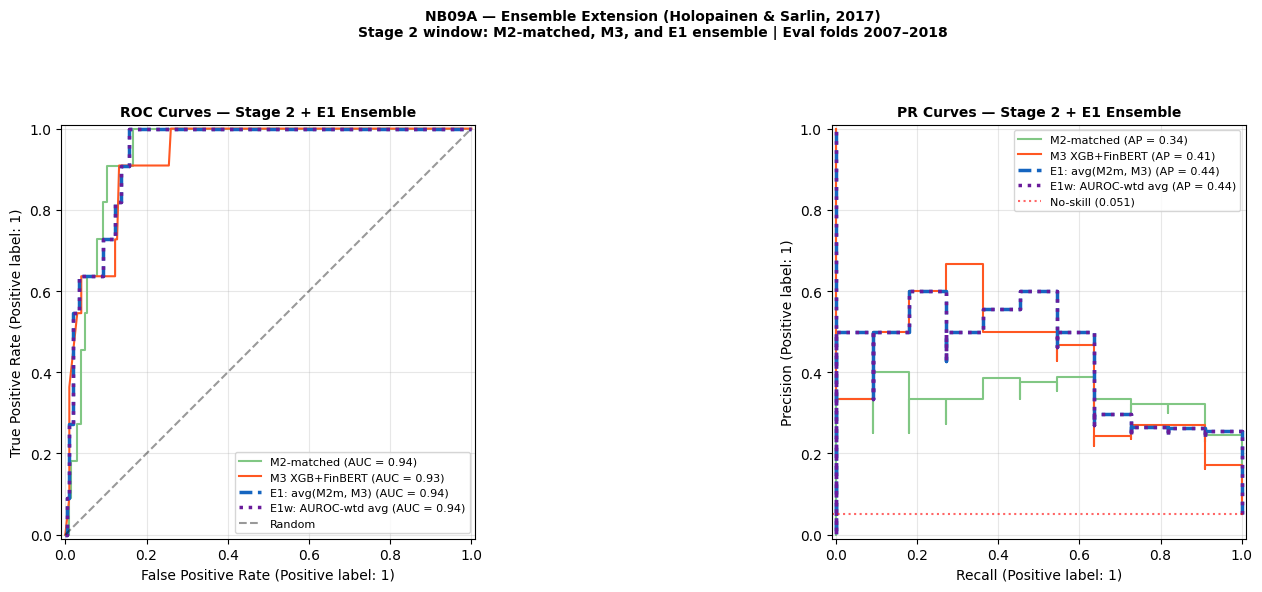

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\NB09A_ensemble_curves_stage2.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'NB09A — Ensemble Extension (Holopainen & Sarlin, 2017)\n'
    'Stage 2 window: M2-matched, M3, and E1 ensemble | Eval folds 2007–2018',
    fontweight='bold', fontsize=10
)

# Palette: component models lighter, ensembles bold
plot_specs = [
    ('M2-matched',            e1['prob_m2m'], y_e1, '#81C784', '-',  1.5),
    ('M3 XGB+FinBERT',        e1['prob_m3'],  y_e1, '#FF5722', '-',  1.5),
    ('E1: avg(M2m, M3)',      e1['prob_e1'],  y_e1, '#1565C0', '--', 2.5),
    ('E1w: AUROC-wtd avg',    e1['prob_e1w'], y_e1, '#6A1B9A', ':',  2.5),
]

for name, probs, ys, col, ls, lw in plot_specs:
    RocCurveDisplay.from_predictions(ys, probs, name=name, ax=axes[0],
                                     color=col, linestyle=ls, linewidth=lw)
    PrecisionRecallDisplay.from_predictions(ys, probs, name=name, ax=axes[1],
                                            color=col, linestyle=ls, linewidth=lw)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curves — Stage 2 + E1 Ensemble', fontweight='bold', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, alpha=0.3)

base_s2 = e1[TARGET].mean()
axes[1].axhline(base_s2, color='red', linestyle=':', alpha=0.6,
                label=f'No-skill ({base_s2:.3f})')
axes[1].set_title('PR Curves — Stage 2 + E1 Ensemble', fontweight='bold', fontsize=10)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.92])
fig_path = FIG_DIR / 'NB09A_ensemble_curves_stage2.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

## Cell 9 — Cross-stage ROC and PR curves

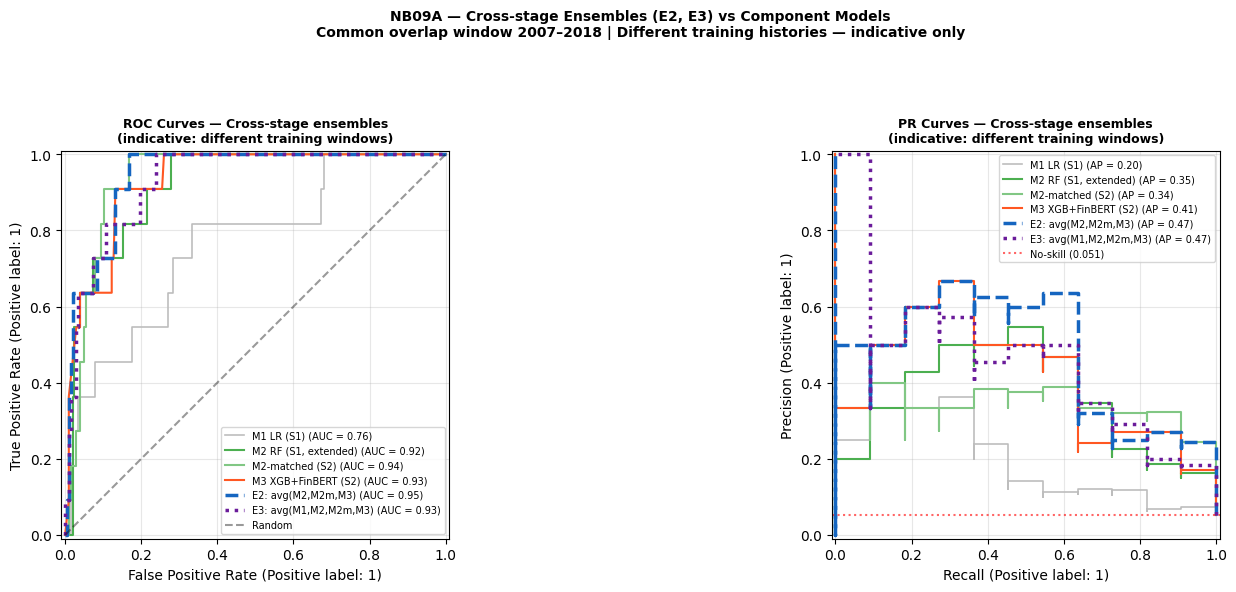

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\NB09A_ensemble_curves_crossstage.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'NB09A — Cross-stage Ensembles (E2, E3) vs Component Models\n'
    'Common overlap window 2007–2018 | Different training histories — indicative only',
    fontweight='bold', fontsize=10
)

plot_specs_cs = [
    ('M1 LR (S1)',            overlap['prob_m1'],  y_ovl, '#BDBDBD', '-',  1.2),
    ('M2 RF (S1, extended)',  overlap['prob_m2'],  y_ovl, '#4CAF50', '-',  1.5),
    ('M2-matched (S2)',       overlap['prob_m2m'], y_ovl, '#81C784', '-',  1.5),
    ('M3 XGB+FinBERT (S2)',   overlap['prob_m3'],  y_ovl, '#FF5722', '-',  1.5),
    ('E2: avg(M2,M2m,M3)',    overlap['prob_e2'],  y_ovl, '#1565C0', '--', 2.5),
    ('E3: avg(M1,M2,M2m,M3)', overlap['prob_e3'], y_ovl, '#6A1B9A', ':',  2.5),
]

for name, probs, ys, col, ls, lw in plot_specs_cs:
    RocCurveDisplay.from_predictions(ys, probs, name=name, ax=axes[0],
                                     color=col, linestyle=ls, linewidth=lw)
    PrecisionRecallDisplay.from_predictions(ys, probs, name=name, ax=axes[1],
                                            color=col, linestyle=ls, linewidth=lw)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curves — Cross-stage ensembles\n(indicative: different training windows)',
                  fontweight='bold', fontsize=9)
axes[0].legend(loc='lower right', fontsize=7)
axes[0].grid(True, alpha=0.3)

base_ovl = overlap[TARGET].mean()
axes[1].axhline(base_ovl, color='red', linestyle=':', alpha=0.6,
                label=f'No-skill ({base_ovl:.3f})')
axes[1].set_title('PR Curves — Cross-stage ensembles\n(indicative: different training windows)',
                  fontweight='bold', fontsize=9)
axes[1].legend(loc='upper right', fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.90])
fig_path_cs = FIG_DIR / 'NB09A_ensemble_curves_crossstage.png'
fig.savefig(fig_path_cs, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path_cs}')

## Cell 10 — Summary results table and save to CSV

In [21]:
# Assemble full results for saving
all_results = []

# Context A rows — add context tag
for r in ctx_a_results:
    all_results.append({**r, 'Context': 'A: Stage 2 window', 'n_obs': len(e1), 'n_crisis': int(e1[TARGET].sum())})
# E1w
all_results.append({**r_e1w, 'Context': 'A: Stage 2 window', 'n_obs': len(e1), 'n_crisis': int(e1[TARGET].sum())})

# Context B rows
for r in ctx_b_results:
    all_results.append({**r, 'Context': 'B: Cross-stage overlap', 'n_obs': len(overlap), 'n_crisis': int(overlap[TARGET].sum())})

df_results = pd.DataFrame(all_results)
df_results = df_results.round(4)

# Save
results_path = OUT_DIR / 'oos_predictions_ensemble.csv'
df_results.to_csv(results_path, index=False)
print(f'Results saved → {results_path}')
print()

# Print final clean summary
print('=' * 120)
print(' FINAL ENSEMBLE SUMMARY — NB09A')
print('=' * 120)
print(f' {"Context":<24} {"Model":<48} {"AUROC":>7} {"AUPRC":>7} {"Brier":>7} {"Lift":>5}')
print('-' * 120)
for _, r in df_results.iterrows():
    print(f' {r.Context:<24} {r.Label:<48} {r.AUROC:>7.4f} {r.AUPRC:>7.4f} {r.Brier:>7.4f} {r.AUPRC_lift:>5.1f}x')
print('=' * 120)
print()

# Dissertation-relevant deltas (Context A only — the primary comparison)
ctx_a = df_results[df_results.Context == 'A: Stage 2 window'].set_index('Label')
m2m_auprc = ctx_a.loc['M2-matched (S2)', 'AUPRC']
m3_auprc  = ctx_a.loc['M3 XGB+FinBERT (S2)', 'AUPRC']
e1_auprc  = ctx_a.loc['E1: avg(M2m, M3) — Stage 2 ensemble', 'AUPRC']

print('Context A deltas (AUPRC, primary metric):')
print(f'  M2-matched baseline         : {m2m_auprc:.4f}')
print(f'  M3 vs M2-matched            : +{m3_auprc - m2m_auprc:+.4f}  ({100*(m3_auprc/m2m_auprc - 1):.1f}%)')
print(f'  E1 vs M2-matched            : +{e1_auprc - m2m_auprc:+.4f}  ({100*(e1_auprc/m2m_auprc - 1):.1f}%)')
print(f'  E1 vs M3                    : {e1_auprc - m3_auprc:+.4f}')
print()
print('Interpretation:')
print('  If E1 > M3 > M2m: ensemble adds value beyond best single model.')
print('  If E1 ≈ M3:       ensemble smooths variance but M3 already near-ceiling.')
print('  If E1 < M3:       M2-matched drag more than offset by variance reduction.')

Results saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\oos_predictions_ensemble.csv

 FINAL ENSEMBLE SUMMARY — NB09A
 Context                  Model                                              AUROC   AUPRC   Brier  Lift
------------------------------------------------------------------------------------------------------------------------
 A: Stage 2 window        M2-matched (S2)                                   0.9385  0.3428  0.0602   6.7x
 A: Stage 2 window        M3 XGB+FinBERT (S2)                               0.9316  0.4110  0.0608   8.0x
 A: Stage 2 window        E1: avg(M2m, M3) — Stage 2 ensemble               0.9430  0.4396  0.0566   8.6x
 A: Stage 2 window        E1w: AUROC-weighted avg(M2m, M3)                  0.9430  0.4396  0.0566   8.6x
 B: Cross-stage overlap   M1 LR (S1, extended)                              0.7643  0.1958  0.2401   3.8x
 B: Cross-stage overlap   M2 RF (S1, extended)                              0.9193  0.3540  0.0

## Cell 11 — NB09A complete

All ensemble variants computed, compared and saved.

In [23]:
print('=' * 65)
print(' NB09A ENSEMBLE EXTENSION COMPLETE')
print('=' * 65)
print()
print('Ensembles evaluated:')
print('  E1  — Stage 2 equal-weighted avg(M2-matched, M3)')
print('  E1w — Stage 2 AUROC-weighted avg(M2-matched, M3)')
print('  E2  — Cross-stage avg(M2_S1, M2-matched, M3)  [indicative]')
print('  E3  — Cross-stage avg(M1_S1, M2, M2-matched, M3)  [indicative]')
print()
print('Files saved:')
print(f'  {results_path.name}')
print(f'  NB09A_ensemble_curves_stage2.png')
print(f'  NB09A_ensemble_curves_crossstage.png')
print()
print('Chapter 4 additions required:')
print('  — One new row in Table 4.2 (E1 ensemble, Context A metrics)')
print('  — Short paragraph in Section 4.2 framing ensemble as Holopainen & Sarlin (2017)')
print('  — Cross-stage ensembles noted in footnote or appendix (indicative only)')
print('  — One sentence update in Section 4.9 hypothesis assessment')

 NB09A ENSEMBLE EXTENSION COMPLETE

Ensembles evaluated:
  E1  — Stage 2 equal-weighted avg(M2-matched, M3)
  E1w — Stage 2 AUROC-weighted avg(M2-matched, M3)
  E2  — Cross-stage avg(M2_S1, M2-matched, M3)  [indicative]
  E3  — Cross-stage avg(M1_S1, M2, M2-matched, M3)  [indicative]

Files saved:
  oos_predictions_ensemble.csv
  NB09A_ensemble_curves_stage2.png
  NB09A_ensemble_curves_crossstage.png

Chapter 4 additions required:
  — One new row in Table 4.2 (E1 ensemble, Context A metrics)
  — Short paragraph in Section 4.2 framing ensemble as Holopainen & Sarlin (2017)
  — Cross-stage ensembles noted in footnote or appendix (indicative only)
  — One sentence update in Section 4.9 hypothesis assessment
